In [25]:
 ## Importing Libraries 
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

In [3]:
dataset= tf.keras.preprocessing.image_dataset_from_directory(
     "Tomatos",
     shuffle=True,
     image_size=(255,255),
        batch_size=32
 )
dataset

Found 5452 files belonging to 4 classes.


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 255, 255, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [4]:
class_name=dataset.class_names
class_name

['Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_healthy']

In [6]:
len(dataset)

171

In [7]:
for x, y in dataset.take(1):
    print(x.shape)
    print(y)

(32, 255, 255, 3)
tf.Tensor([3 1 1 0 3 1 3 2 1 3 1 1 1 3 2 1 1 3 2 1 0 3 2 2 3 3 1 1 1 1 0 1], shape=(32,), dtype=int32)


#### 🔹 Visualize a batch of images

<Figure size 1000x1000 with 0 Axes>

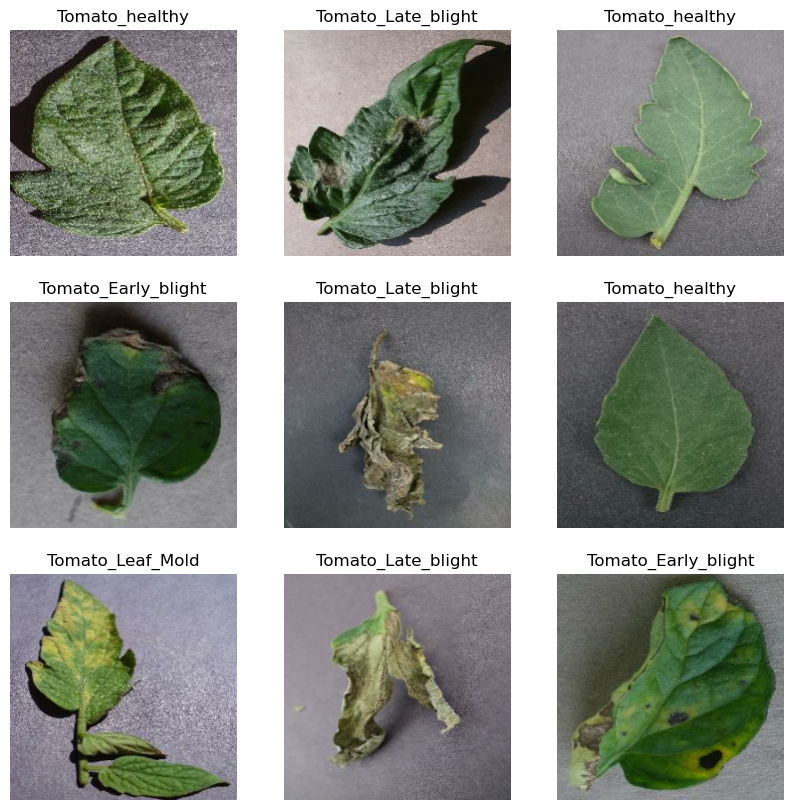

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
for x, labels in dataset.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):  # show first 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(x[i].numpy().astype("uint8"))
        plt.title(class_name[labels[i].numpy()])
        plt.axis("off")

In [ ]:
## Train test and validation dataset

In [10]:
total_batches = len(dataset)

train_size = int(total_batches * 0.8)
val_size   = int(total_batches * 0.1)
test_size  = int(total_batches * 0.1)

train_data = dataset.take(train_size)
val_data   = dataset.skip(train_size).take(val_size)
test_data  = dataset.skip(train_size + val_size).take(test_size)


### Preprocessig

In [11]:
input_shape = (32, 255, 255, 3)


In [12]:
##Resize and Rescaling(Nomalize) Images 
resize_and_rescale=tf.keras.Sequential([layers.Resizing(255,255),layers.Rescaling(1./255,input_shape=(input_shape))])

##Apply Data Augmentation
data_augmentation=tf.keras.Sequential([layers.RandomRotation(.2),layers.RandomFlip("horizontal_and_vertical")])

train_data=train_data.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
test_data=test_data.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_data=val_data.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)

C:\Users\User\anaconda3\envs\ml-zoomcamp\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# . MODEL

In [16]:

model = models.Sequential([
        resize_and_rescale,
    data_augmentation,
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)), 
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(units=64, activation='relu'),
    layers.Dense(units=4, activation='softmax') # Outputs 3 class probabilities
])
model.build(input_shape=input_shape)
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (32, 255, 255, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (32, 255, 255, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (32, 255, 255, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (32, 127, 127, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (32, 127, 127, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (32, 63, 63, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (32, 61, 61, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (32, 30, 30, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (32, 30, 30, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (32, 15, 15, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (32, 13, 13, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (32, 6, 6, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (32, 2304)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (32, 64)                    │         147,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (32, 4)                     │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 277,956 (1.06 MB)

 Trainable params: 277,956 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

##  TRAINING


In [18]:
epochs=10
history = model.fit(
  train_data,
  validation_data=val_data,
  epochs=epochs
)

Epoch 1/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 218s 2s/step - accuracy: 0.3778 - loss: 1.3134 - val_accuracy: 0.4099 - val_loss: 1.2535
Epoch 2/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.5965 - loss: 0.9116 - val_accuracy: 0.7518 - val_loss: 0.5902
Epoch 3/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 209s 2s/step - accuracy: 0.7254 - loss: 0.6529 - val_accuracy: 0.8272 - val_loss: 0.4535
Epoch 4/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 243s 1s/step - accuracy: 0.8187 - loss: 0.4682 - val_accuracy: 0.8732 - val_loss: 0.3990
Epoch 5/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 217s 2s/step - accuracy: 0.8334 - loss: 0.4292 - val_accuracy: 0.7978 - val_loss: 0.5758
Epoch 6/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step - accuracy: 0.8704 - loss: 0.3339 - val_accuracy: 0.8768 - val_loss: 0.3729
Epoch 7/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.8867 - loss: 0.3004 - val_accuracy: 0.9136 - val_loss: 0.2302
Epoch 8/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.8987 - loss: 0.2632 - val_accu

In [15]:
history.params

{'verbose': 'auto', 'epochs': 10, 'steps': 54}

##  TRAINING CURVES

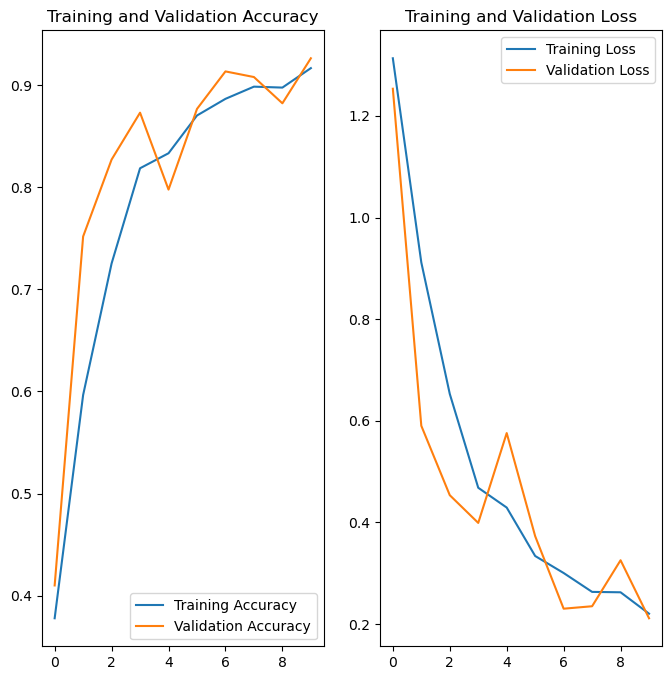

In [19]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [20]:
test_loss, test_accuracy = model.evaluate(test_data)
print(f"\nTest loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
 

17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 254ms/step - accuracy: 0.9173 - loss: 0.2278

Test loss: 0.2278
Test accuracy: 0.9173


### FULL CONFUSION MATRIX + CLASSIFICATION REPORT

In [23]:
 # FULL CONFUSION MATRIX + CLASSIFICATION REPORT
y_true = []
y_pred = []
 
for images, labels in test_data:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())
 
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_name))
 
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))
 


Classification Report:
                     precision    recall  f1-score   support

Tomato_Early_blight       0.89      0.79      0.84       102
 Tomato_Late_blight       0.90      0.90      0.90       185
   Tomato_Leaf_Mold       0.92      0.93      0.93        90
     Tomato_healthy       0.94      1.00      0.97       167

           accuracy                           0.92       544
          macro avg       0.91      0.91      0.91       544
       weighted avg       0.92      0.92      0.92       544

Confusion Matrix:
[[ 81  17   1   3]
 [  9 167   6   3]
 [  1   1  84   4]
 [  0   0   0 167]]


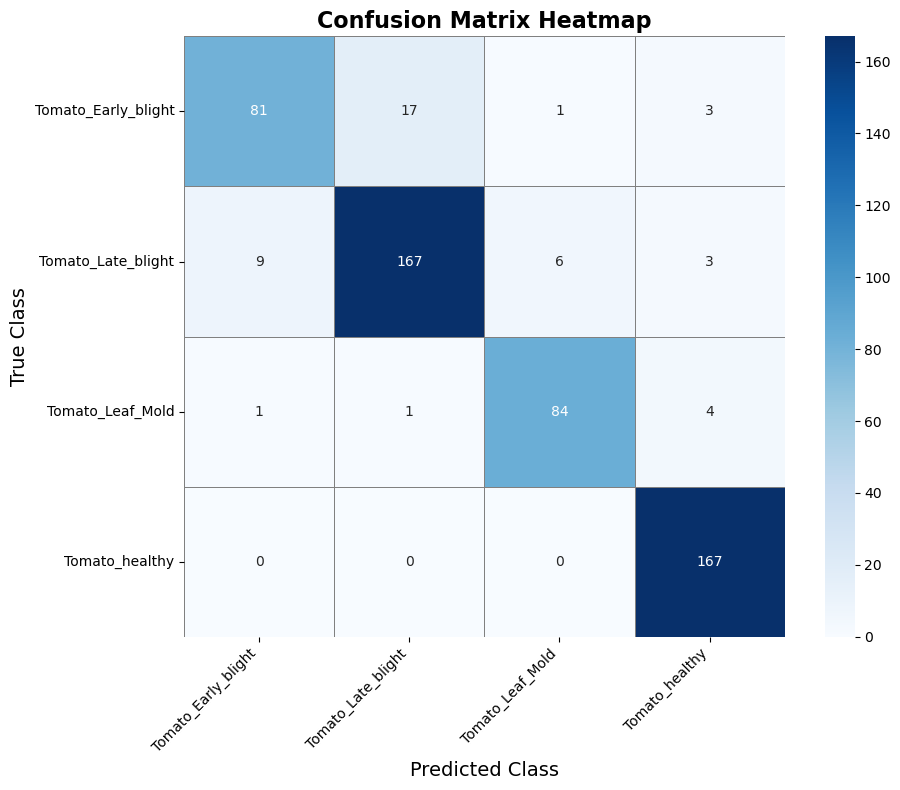

In [26]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True,           # Show numbers in cells
    fmt='d',              # Integer format
    cmap='Blues',         # Color scheme (try 'Reds', 'Greens', 'viridis')
    xticklabels=class_name,
    yticklabels=class_name,
    cbar=True,
    square=True,          # Make cells square
    linewidths=0.5,       # Add grid lines
    linecolor='gray'
)


plt.title('Confusion Matrix Heatmap', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=14)
plt.ylabel('True Class', fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

### Saving the Model
We append the model to the list of models as a new version

In [17]:
os.makedirs("../models", exist_ok=True)
 
# Auto-increment version so you don't overwrite previous runs
existing_versions = [
    int(f.split(".")[0]) for f in os.listdir("../models")
    if f.endswith(".keras") and f.split(".")[0].isdigit()
]
model_version = max(existing_versions, default=0) + 1
 
model.save(f"../models/{model_version}.keras")
 
# Save class names alongside the model - you'll need this at inference time
with open(f"../models/{model_version}_classes.json", "w") as f:
    json.dump({i: name for i, name in enumerate(class_name)}, f)
 
print(f"\nSaved model version {model_version} and its class mapping.")